In [ ]:
# TAREA 2 Reseñas de usuarios

In [ ]:
'''
- Elegir un conjunto de datos de reseñas de usuarios (por ejemplo, reseñas de Amazon, entre otros)
- Elegir un modelo de vectorización adecuado para el conjunto de datos elegido, aplicarlo y estudiar las propiedades de los vectores obtenidos.
- Realizar el preprocesamiento necesario para realizar un análisis de sentimiento que, de ser posible, compare la reseña presentada con alguna clasificación numérica elegida.
'''

In [17]:
# Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.feature_extraction.text import TfidfVectorizer

from nltk.corpus import stopwords

import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [23]:
# Lectura del dataset (recortado a 1000 reseñas del total)
df = pd.read_csv(
    "Reviews.csv",
    engine="python",
    on_bad_lines="skip"
)

df = df[['Score', 'Text']]

df = df.dropna()

df = df.sample(
    n=1000,
    random_state=42
)

df.reset_index(
    drop=True,
    inplace=True
)

print(df.shape)

df.head()

(1000, 2)


,Score,Text
0,5,Having tried a couple of other brands of glute...
1,5,My cat loves these treats. If ever I can't fin...
2,3,A little less than I expected. It tends to ha...
3,2,"First there was Frosted Mini-Wheats, in origin..."
4,5,and I want to congratulate the graphic artist ...


In [24]:
# Distribución de calificaciones
import matplotlib.pyplot as plt

df['Score'].value_counts().sort_index()

,count
Score,
1,95
2,56
3,69
4,151
5,629


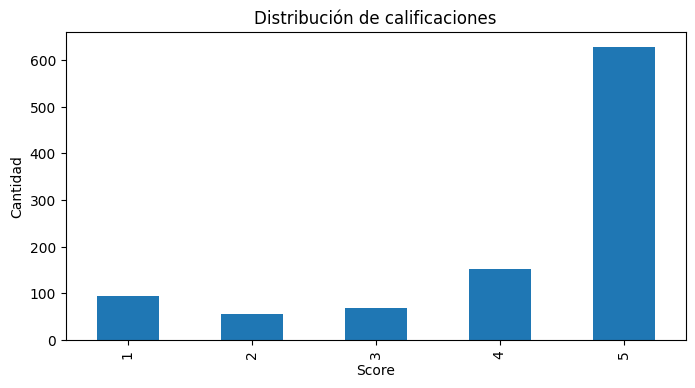

In [25]:
plt.figure(figsize=(8,4))

df['Score'].value_counts().sort_index().plot(
    kind='bar'
)

plt.title('Distribución de calificaciones')

plt.xlabel('Score')

plt.ylabel('Cantidad')

plt.show()

In [26]:
# Preprocesamiento
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

In [27]:
def limpiar_texto(texto):

    texto = str(texto).lower()

    texto = re.sub(r'\d+', '', texto)

    texto = re.sub(r'[^\w\s]', ' ', texto)

    palabras = texto.split()

    palabras = [
        p for p in palabras
        if p not in stop_words
    ]

    return " ".join(palabras)

In [28]:
df['Text_clean'] = df['Text'].apply(
    limpiar_texto
)

In [29]:
df[['Text','Text_clean']].head()

,Text,Text_clean
0,Having tried a couple of other brands of glute...,tried couple brands gluten free sandwich cooki...
1,My cat loves these treats. If ever I can't fin...,cat loves treats ever find house pop top bolts...
2,A little less than I expected. It tends to ha...,little less expected tends muddy taste expecte...
3,"First there was Frosted Mini-Wheats, in origin...",first frosted mini wheats original size froste...
4,and I want to congratulate the graphic artist ...,want congratulate graphic artist putting entir...


In [30]:
# Vectorización TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizador = TfidfVectorizer(
    max_features=1000
)

X = vectorizador.fit_transform(
    df['Text_clean']
)

In [31]:
# Dimensión de la matriz
print(X.shape)
(1000,1000)

(1000, 1000)


(1000, 1000)

In [32]:
# Tamaño y densidad
len(vectorizador.vocabulary_)
densidad = X.nnz/(X.shape[0]*X.shape[1])

print(densidad)

0.024202


In [33]:
# Palabras más importantes según la vectorización
idf = pd.DataFrame({

    'Termino':
        vectorizador.get_feature_names_out(),

    'IDF':
        vectorizador.idf_

})

idf.sort_values(
    'IDF',
    ascending=False
).head(20)

,Termino,IDF
380,graham,6.522460
467,lamb,6.522460
347,frosting,6.522460
571,noodle,6.522460
578,numi,6.522460
160,cod,6.522460
800,soap,6.522460
239,dissolve,6.522460
731,rocks,6.522460
410,herbs,6.522460


In [35]:
# Palabras más frecuentes
frecuencias = pd.Series(
    ' '.join(df['Text_clean'])
    .split()
).value_counts()

frecuencias.head(20)

,count
br,1126
like,470
good,346
taste,324
one,320
product,305
great,278
coffee,273
tea,269
flavor,241


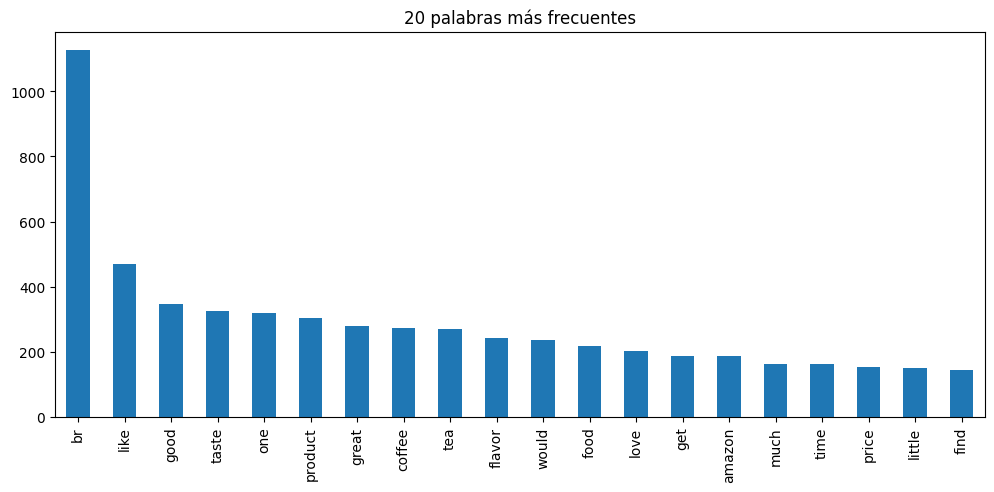

In [36]:
plt.figure(figsize=(12,5))

frecuencias.head(20).plot(
    kind='bar'
)

plt.title(
    '20 palabras más frecuentes'
)

plt.show()

In [37]:
# Análisis de sentimiento
'''Se inserta léxico'''
import nltk

nltk.download('vader_lexicon')

'''luego se crea analizador'''
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

'''y se crea el score'''
df['sentiment_score'] = df['Text'].apply(

    lambda x:
    sia.polarity_scores(str(x))['compound']

)

# clasificación
def clasificar(score):

    if score > 0.05:
        return "Positivo"

    elif score < -0.05:
        return "Negativo"

    else:
        return "Neutral"

df['Sentimiento'] = df[
    'sentiment_score'
].apply(clasificar)

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [38]:
# Conteo
df['Sentimiento'].value_counts()

,count
Sentimiento,
Positivo,884
Negativo,97
Neutral,19


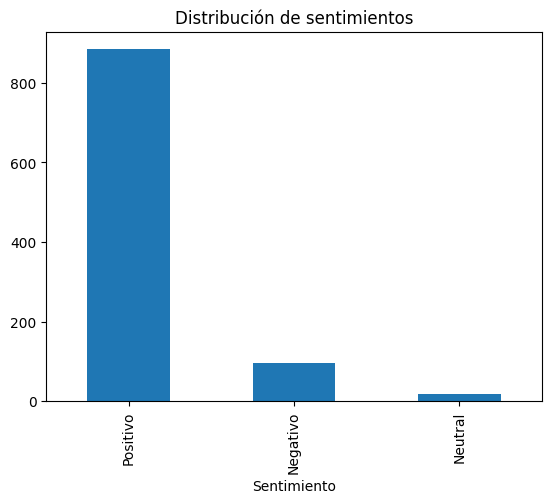

In [39]:
df['Sentimiento'].value_counts().plot(
    kind='bar'
)

plt.title(
    'Distribución de sentimientos'
)

plt.show()